Q4, part b

First, we use CVX to find $f^*$. We then compare this with the subgradient output for different stepsizes. We can observe that Polyak stepsize has the best convergence rate and eventually the error reduces to floating point error. It is the same with $\eta_t = \frac{1}{\sqrt{t+1}}$, though not as fast. Both converge within 700 iterations. However, the constant stepsize ($\eta = 0.01$) and square summable stepsize ($\eta_t = \frac{2}{\mu(+1)}$) do not converge as rapidly. 

In [ ]:
import cvxpy as cp
import numpy as np

# First, use CVX to find the f^*

n, p, q = 5, 3, 6
A = [np.random.randn(p, q) for i in range(n)]
B = np.random.randn(p, q)

x_var = cp.Variable(n)
expr = cp.sum([x_var[i] * A[i] for i in range(n)]) - B
prob = cp.Problem(cp.Minimize(cp.norm(expr, 2)))
f_star = prob.solve() 

print(f"Optimal Value from CVXPY: {f_star:.6f}")

Optimal Value from CVXPY: 3.569732



Running: Polyak
  Iter 0: f_best - f* = 9.90039986e-01
  Iter 50: f_best - f* = 5.50259019e-07
  Iter 100: f_best - f* = 1.12044152e-10
  Iter 150: f_best - f* = 1.42450496e-11
  Iter 200: f_best - f* = 3.37863071e-12
  Iter 250: f_best - f* = 8.88622509e-13
  Iter 300: f_best - f* = 2.39808173e-13
  Iter 350: f_best - f* = 6.48370246e-14
  Iter 400: f_best - f* = 1.77635684e-14
  Iter 450: f_best - f* = 4.44089210e-15
  Iter 500: f_best - f* = 4.44089210e-16
  Iter 550: f_best - f* = 0.00000000e+00
  Iter 600: f_best - f* = 0.00000000e+00
  Iter 650: f_best - f* = 0.00000000e+00

Running: Constant (0.01)
  Iter 0: f_best - f* = 9.90039986e-01
  Iter 50: f_best - f* = 2.40823261e-01
  Iter 100: f_best - f* = 3.07608139e-02
  Iter 150: f_best - f* = 1.14817381e-02
  Iter 200: f_best - f* = 8.64683918e-03
  Iter 250: f_best - f* = 6.96297957e-03
  Iter 300: f_best - f* = 5.71829681e-03
  Iter 350: f_best - f* = 4.73223096e-03
  Iter 400: f_best - f* = 3.92968990e-03
  Iter 450: f_best -

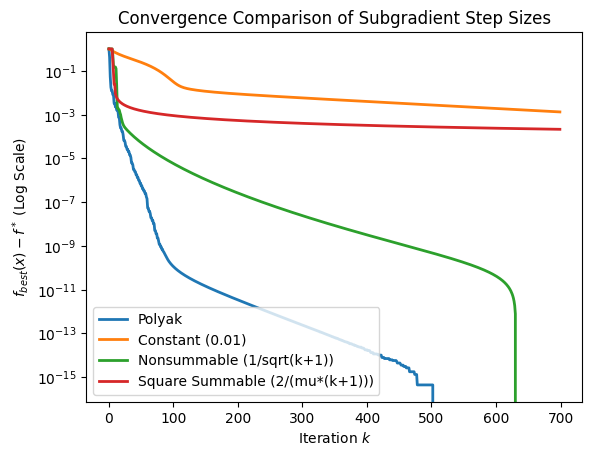

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_subgradient(x_val):
    M = sum(x_val[i] * A[i] for i in range(n)) - B
    u, s, vh = np.linalg.svd(M, full_matrices=False)
    f_val = s[0]
    g = np.array([u[:, 0].T @ A[i] @ vh[0, :] for i in range(n)]) # g_i = u_1^T * A_i * v_1
    return f_val, g

# step sizes to test
step_rules = {
    "Polyak": lambda k, f, g: (f - f_star) / (np.linalg.norm(g)**2 + 1e-9),
    "Constant (0.01)": lambda k, f, g: 0.01,
    "Nonsummable (1/sqrt(k+1))": lambda k, f, g: 1.0 / np.sqrt(k + 1),
    "Square Summable (2/(mu*(k+1)))": lambda k, f, g: 2.0 / (mu * (k + 1))
}

results = {}
iters = 700
mu = 1

for name, rule_func in step_rules.items():
    x = np.zeros(n)
    f_best_history = []
    f_best = float('inf')
    
    print(f"\nRunning: {name}")
    for k in range(iters):
        f_curr, g = get_subgradient(x)
        
        if f_curr < f_best:
            f_best = f_curr
        f_best_history.append(f_best)
        
        step_size = rule_func(k, f_curr, g)
        x = x - step_size * g
        
        if k % 50 == 0:
            print(f"  Iter {k}: f_best - f* = {f_best - f_star:.8e}")
            
    results[name] = np.array(f_best_history)

# Plot

plt.figure()

for name, history in results.items():
    plt.semilogy(history - f_star, label=name, linewidth=2)

plt.xlabel('Iteration $k$')
plt.ylabel('$f_{best}(x) - f^*$ (Log Scale)')
plt.title('Convergence Comparison of Subgradient Step Sizes')
plt.legend()
plt.show()